# Quickstart: DWD ICON-EU forecast, 5 day - dynamical.org Icechunk Zarr

ICON-EU is the regional, high-resolution configuration of Deutscher Wetterdienst's (DWD) ICON numerical weather model. It produces 5-day forecasts covering Europe at 0.0625 degree (~7 km) resolution.

This dataset provides DWD ICON-EU 5-day forecasts from February 2026 to present, transformed into a single analysis-ready dataset by [dynamical.org](https://dynamical.org).

Dataset documentation: https://dynamical.org/catalog/dwd-icon-eu-forecast-5-day/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install -q "xarray[complete]>=2025.3.0" "zarr>=3.0.8" icechunk

In [2]:
import icechunk
import xarray as xr

storage = icechunk.s3_storage(bucket="dynamical-dwd-icon-eu", prefix="dwd-icon-eu-forecast-5-day/v0.2.0.icechunk", region="us-west-2", anonymous=True)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")
ds = xr.open_zarr(session.store, chunks=None)
ds

<xarray.Dataset> Size: 2TB
Dimensions:                                             (init_time: 283,
                                                         lead_time: 93,
                                                         latitude: 657,
                                                         longitude: 1377)
Coordinates:
  * init_time                                           (init_time) datetime64[ns] 2kB ...
    expected_forecast_length                            (init_time) timedelta64[ns] 2kB ...
    ingested_forecast_length                            (init_time) timedelta64[ns] 2kB ...
  * lead_time                                           (lead_time) timedelta64[ns] 744B ...
    valid_time                                          (init_time, lead_time) datetime64[ns] 211kB ...
  * latitude                                            (latitude) float64 5kB ...
  * longitude                                           (longitude) float64 11kB ...
    spatial_ref                                         int64 8B ...
Data variables: (12/19)
    cloud_cover_high                                    (init_time, lead_time, latitude, longitude) float32 95GB ...
    cloud_cover_medium                                  (init_time, lead_time, latitude, longitude) float32 95GB ...
    cloud_cover_low                                     (init_time, lead_time, latitude, longitude) float32 95GB ...
    convective_available_potential_energy_atmosphere    (init_time, lead_time, latitude, longitude) float32 95GB ...
    downward_diffuse_short_wave_radiation_flux_surface  (init_time, lead_time, latitude, longitude) float32 95GB ...
    dew_point_temperature_2m                            (init_time, lead_time, latitude, longitude) float32 95GB ...
    ...                                                  ...
    temperature_2m                                      (init_time, lead_time, latitude, longitude) float32 95GB ...
    snow_water_equivalent_surface                       (init_time, lead_time, latitude, longitude) float32 95GB ...
    wind_u_10m                                          (init_time, lead_time, latitude, longitude) float32 95GB ...
    total_cloud_cover_atmosphere                        (init_time, lead_time, latitude, longitude) float32 95GB ...
    wind_v_10m                                          (init_time, lead_time, latitude, longitude) float32 95GB ...
    wind_gust_10m                                       (init_time, lead_time, latitude, longitude) float32 95GB ...
Attributes:
    dataset_id:           dwd-icon-eu-forecast-5-day
    dataset_version:      0.2.0
    name:                 DWD ICON-EU forecast, 5 Day
    description:          High-resolution weather forecasts for Europe from t...
    attribution:          DWD ICON-EU data processed by dynamical.org.
    license:              CC BY 4.0
    spatial_domain:       Europe
    spatial_resolution:   0.0625 degrees (~7km)
    time_domain:          Forecasts initialized 2026-02-10 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-120 hours (0-5 days) ahead
    forecast_resolution:  Forecast step 0-78 hours: hourly, 81-120 hours: 3 h...

This is a forecast dataset with two time dimensions: `init_time` (when the forecast run began) and `lead_time` (how far ahead the forecast extends). The `valid_time` coordinate combines these to give the actual forecasted time.

It covers Europe on a regular latitude/longitude grid at 0.0625° (~7 km) resolution, with hourly steps out to 78 hours and 3-hourly steps to 120 hours. Let's start with a forecast time series at a point, then a map at a single time step.

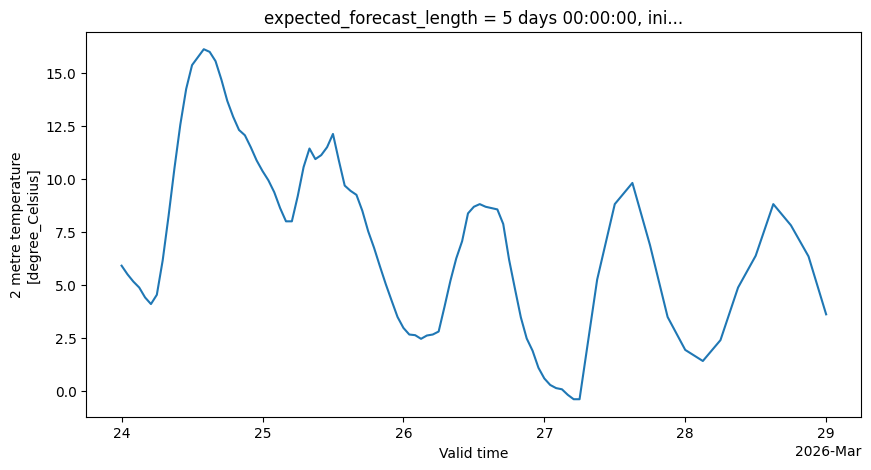

In [3]:
# 5-day temperature forecast for Berlin, initialized as a springtime Arctic blast was moving in.
# You can see the diurnal cycle ride on top of a 10°C cooling trend from warm "false spring" to hard frost.
plot_ds = ds.sel(init_time="2026-03-24T00", latitude=52.52, longitude=13.40, method="nearest")
_ = plot_ds["temperature_2m"].plot(x="valid_time", figsize=(10, 5))

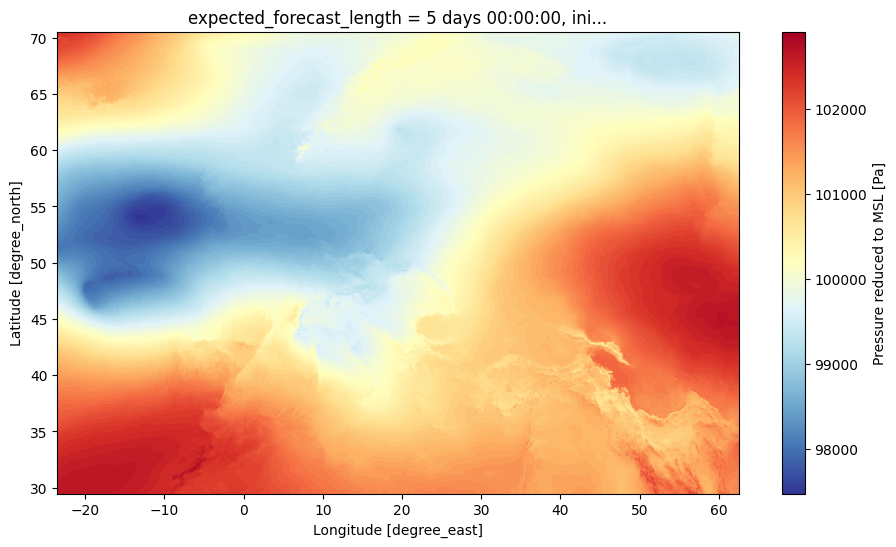

In [4]:
# Mean sea level pressure reveals the highs and lows that steer Europe's weather.
# This snapshot, from a forecast initialized just as Storm Nils was spinning up over
# the Bay of Biscay, shows a ~975 hPa low (blue) about to move into France.
(
    ds["pressure_reduced_to_mean_sea_level"]
    .sel(init_time="2026-02-10T00", lead_time="36h")
    .plot(figsize=(11, 6), cmap="RdYlBu_r")
)

### How strong were the winds during Storm Nils?

Storm Nils struck southwest France and Iberia on 11-12 February 2026 with gusts over 180 km/h, the most damaging storm for the region since Klaus in 2009. It knocked out power for ~900,000 French customers and triggered a rare red avalanche alert in Savoie. Let's map the forecast 10m wind gust at the storm's peak.

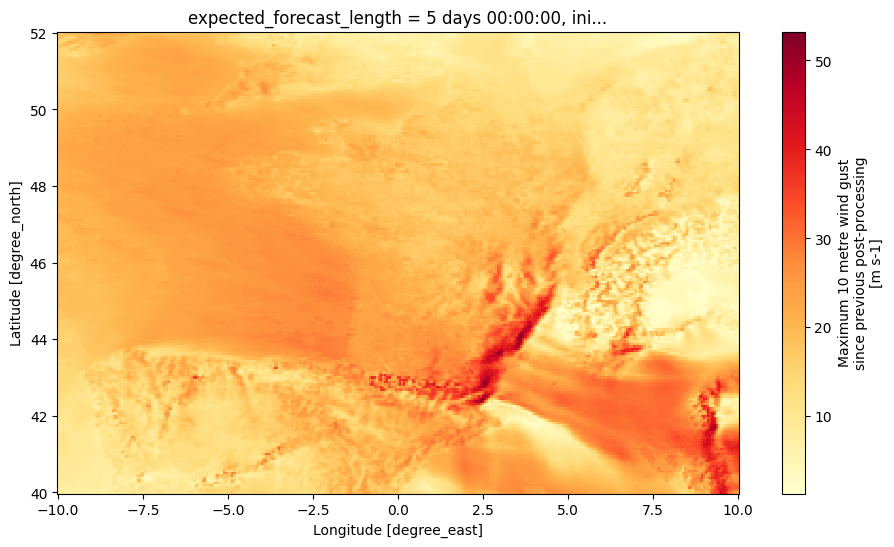

In [5]:
# 10m wind gust over western Europe when Storm Nils crossed southwest France,
# valid 2026-02-12 14 UTC. Forecast peak gusts around 190 km/h (53 m/s) inland.
gust = ds["wind_gust_10m"].sel(
    init_time="2026-02-10T00",
    lead_time="62h",
    latitude=slice(52, 40),
    longitude=slice(-10, 10),
)
gust.plot(figsize=(11, 6), cmap="YlOrRd")

### How did the late-March Arctic blast reshape temperatures across Europe?

After a week of "false spring" warmth (5-8°C above normal), a Siberian cold core swept across Europe on 24-27 March 2026, dropping temperatures 15-20°C in two days and bringing late-season snow to Central European lowlands. A single 5-day forecast run straddles the whole transition — we can visualize it as a map of temperature change.

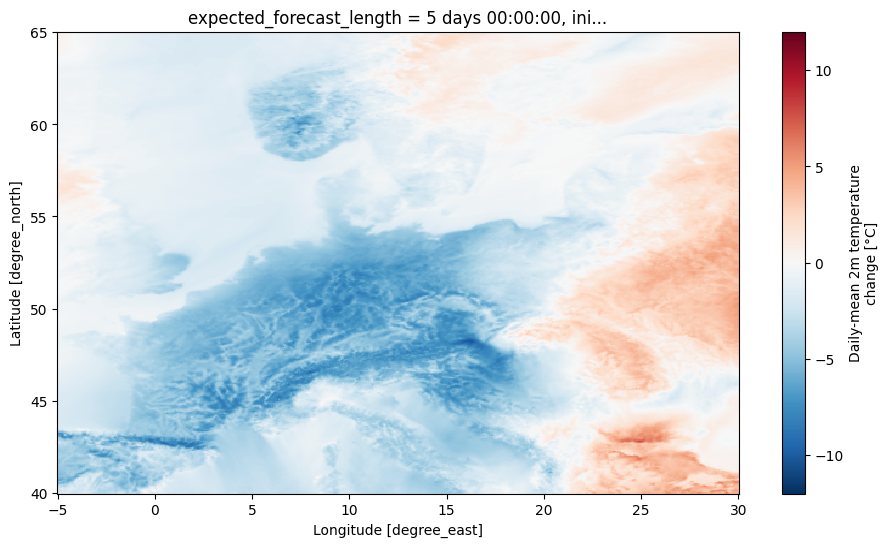

In [6]:
# Temperature difference between a pre-blast daily mean and a post-blast daily mean,
# from one forecast run that spans both regimes
forecast = ds.sel(init_time="2026-03-23T00", latitude=slice(65, 40), longitude=slice(-5, 30))

before = forecast["temperature_2m"].sel(lead_time=slice("24h", "47h")).mean("lead_time")
after = forecast["temperature_2m"].sel(lead_time=slice("96h", "119h")).mean("lead_time")
change = (after - before).load()
change.attrs["units"] = "°C"
change.attrs["long_name"] = "Daily-mean 2m temperature change"

change.plot(figsize=(11, 6), cmap="RdBu_r", vmin=-12, vmax=12)

### How does cloud cover layer up as a front passes through?

ICON-EU reports cloud cover at low, medium, and high levels separately. This is useful for understanding cloud structure, not just total obscuration. Stacking these for a single location during a forecast run reveals the vertical signature of approaching fronts.

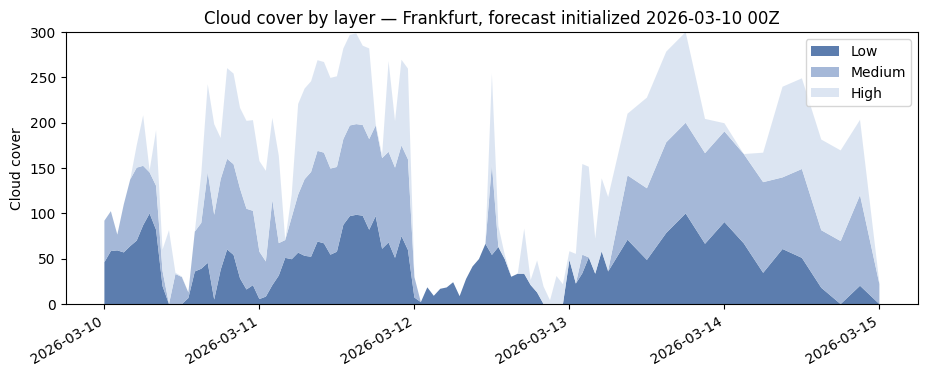

In [7]:
import matplotlib.pyplot as plt

# Stack low / medium / high cloud cover for Frankfurt across a 5-day forecast
plot_ds = ds.sel(init_time="2026-03-10T00", latitude=50.11, longitude=8.68, method="nearest")
vt = plot_ds["valid_time"].values

fig, ax = plt.subplots(figsize=(11, 4))
ax.stackplot(
    vt,
    plot_ds["cloud_cover_low"].values,
    plot_ds["cloud_cover_medium"].values,
    plot_ds["cloud_cover_high"].values,
    labels=["Low", "Medium", "High"],
    colors=["#4a6fa5", "#9bb1d4", "#d9e3f1"],
    alpha=0.9,
)
ax.set_ylabel("Cloud cover")
ax.set_title("Cloud cover by layer — Frankfurt, forecast initialized 2026-03-10 00Z")
ax.set_ylim(0, 300)  # stacked sum; each layer independently 0-100
ax.legend(loc="upper right")
fig.autofmt_xdate()

### Animated map

Precipitation at ICON-EU's 7 km resolution really shines. With a 5-day forecast animation we can see frontal bands, orographic enhancement over the Alps, and convective cells.

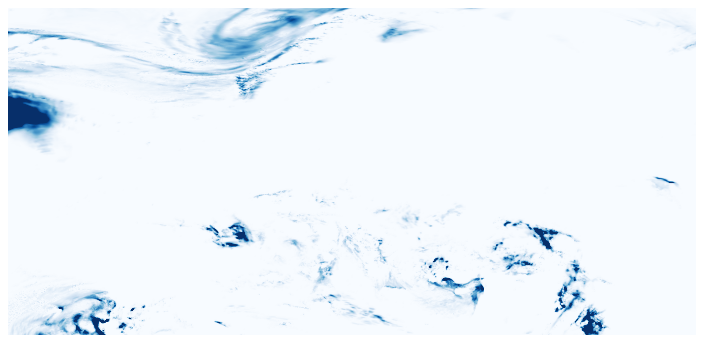

In [8]:
import pandas as pd
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# Animation of precipitation rate through the hourly portion of the forecast (0-78 h).
# Sampling every 2 hours to keep the notebook small, increase for smoother animation.
data = (
    ds["precipitation_surface"]
    .sel(init_time="2026-03-23T00", lead_time=pd.timedelta_range("2h", "78h", freq="2h"))
    .coarsen(latitude=2, longitude=2, boundary="trim").mean()
    .load()
)

dpi = 80
fig, ax = plt.subplots(figsize=(data.longitude.size / dpi, data.latitude.size / dpi), dpi=dpi)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.axis("off")

img = ax.imshow(data.isel(lead_time=0), cmap="Blues", vmin=0, vmax=5e-4, origin="upper",
                extent=[float(data.longitude[0]), float(data.longitude[-1]),
                        float(data.latitude[-1]), float(data.latitude[0])])
anim = FuncAnimation(fig=fig, frames=data, func=lambda frame: img.set_data(frame), interval=120)

HTML(anim.to_jshtml())

### Community challenge

With ICON-EU's 7 km resolution, 4x daily refresh, and Europe-wide coverage there are lots of interesting questions to explore. A few ideas to build on:

- **Orchard frost risk.** In April, a late frost during blossom can wipe out a year's fruit crop. Map where the 5-day-forecast minimum `temperature_2m` drops below 0°C across Europe's fruit belts (Loire, Rhine-Main, Emilia-Romagna, South Moravia). Where is risk highest, and how far ahead does ICON-EU call it?
- **Do the European wind and solar fleets complement each other?** Construct simple proxies for national wind and solar generation from `wind_u_10m`/`wind_v_10m` (use `|V|³` inside a capacity region) and `downward_direct_short_wave_radiation_flux_surface` + `downward_diffuse_short_wave_radiation_flux_surface`. Then correlate the hourly 5-day-forecast output of large wind regions (North Sea, Iberia) against large solar regions (Spain, Italy, Germany). Do high-wind hours tend to also be low-solar hours (anti-correlated, making the grid easier) or not?